# Task 3: Order Demand Classification Network

In [27]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [28]:
np.random.seed(42)
hour_of_day = np.random.randint(0, 24, 600)
day_of_week = np.random.randint(0, 7, 600)
temperature = np.random.uniform(10, 45, 600)

X = np.column_stack((hour_of_day, day_of_week, temperature))

y_labels = []
for i in range(600):
    h, d, t = hour_of_day[i], day_of_week[i], temperature[i]
    score = 0
    if 18 <= h <= 22: score += 2
    elif 11 <= h <= 14: score += 1
    if d >= 5: score += 1
    if t > 35: score -= 1
    if score >= 2: y_labels.append(2)
    elif score == 1: y_labels.append(1)
    else: y_labels.append(0)
y_labels = np.array(y_labels)

y = to_categorical(y_labels, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [29]:
print(X)

[[ 6.          1.         30.06027972]
 [19.          1.         44.91924156]
 [14.          6.         36.3341092 ]
 ...
 [ 6.          3.         30.92032478]
 [12.          5.         37.75346331]
 [20.          6.         32.92532686]]


In [30]:
y

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], shape=(600, 3))

In [31]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

In [32]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=30, validation_split=0.2)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.3529 - loss: 2.9321 - val_accuracy: 0.4510 - val_loss: 1.2571
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4926 - loss: 2.0528 - val_accuracy: 0.5588 - val_loss: 1.1836
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5123 - loss: 1.6014 - val_accuracy: 0.5882 - val_loss: 0.9291
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4461 - loss: 1.4591 - val_accuracy: 0.6176 - val_loss: 0.7994
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4828 - loss: 1.3365 - val_accuracy: 0.6569 - val_loss: 0.7847
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5221 - loss: 1.1488 - val_accuracy: 0.6176 - val_loss: 0.7881
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5539 - loss: 1.1042 - val_accuracy: 0.6176 - val_loss: 0.7995
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4877 - loss: 1.0761 - val_accuracy: 0.6275 - v

In [33]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {accuracy:.4f}")

Final Test Accuracy: 0.6444


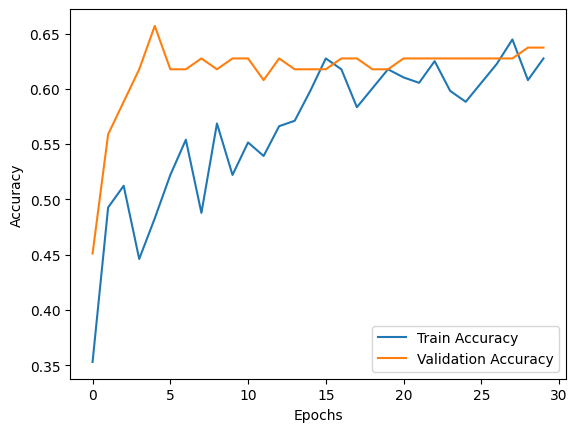

In [34]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [35]:
model.save('demand_model.keras')